In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import RNN_preprocessing_whole as rp 

In [4]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649211904, available=811945984, percent=95.1, used=15286882304, free=250200064, active=495890432, inactive=15385964544, buffers=45023232, cached=1067106304, shared=180121600, slab=316076032)


In [5]:
import gc
gc.collect()

0

In [6]:
print(psutil.virtual_memory()) 

svmem(total=16649211904, available=797192192, percent=95.2, used=15271485440, free=226197504, active=494505984, inactive=15373344768, buffers=45359104, cached=1106169856, shared=210726912, slab=316100608)


In [7]:
X_seq_train = rp.X_seq_train
X_seq_test = rp.X_seq_test
y_seq_train = rp.y_seq_train
y_seq_test = rp.y_seq_test

In [8]:
# Clear memory associated with the module
del rp
if 'RNN_preprocessing_whole' in sys.modules:
    del sys.modules['RNN_preprocessing_whole']

# Clear memory from global variables if needed
gc.collect()

5

In [9]:
X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(X_seq_train, y_seq_train, test_size=0.2, random_state=0)

In [10]:
X_train = X_seq_train
X_val = X_seq_val
y_train = y_seq_train
y_val = y_seq_val 

In [11]:
# Delete the training/test split variables after they are used
del X_seq_train, X_seq_val, y_seq_train, y_seq_val

# Force garbage collection
gc.collect()

0

# RNN

In [12]:
#RNN model
def model_rnn (input_shape, output_shape):
    model = keras.Sequential(
        [
            layers.SimpleRNN(64, input_shape=input_shape, activation="tanh", return_sequences=True),
            layers.SimpleRNN(32, activation="tanh", return_sequences=True),
            layers.Dense(16, activation="relu"),
            layers.Dense(output_shape, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    return model

In [13]:
seq_length = 10

In [14]:
#Model for the BiPo 214 chain
model = model_rnn((seq_length, X_train.shape[2]), y_train.shape[2])

model.summary()

2025-03-26 14:08:15.136942: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 10, 64)            4544      
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 10, 32)            3104      
                                                                 
 dense (Dense)               (None, 10, 16)            528       
                                                                 
 dense_1 (Dense)             (None, 10, 10)            170       
                                                                 
Total params: 8346 (32.60 KB)
Trainable params: 8346 (32.60 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [16]:
# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


950

In [17]:
# Train model 1
history = model.fit(X_train, y_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X_val, y_val),
                      callbacks=callbacks)

Epoch 1/200
16108/16108 - 267s - loss: 0.7464 - accuracy: 0.6770 - val_loss: 0.6734 - val_accuracy: 0.7081 - lr: 0.0010 - 267s/epoch - 17ms/step
Epoch 2/200
16108/16108 - 259s - loss: 0.6770 - accuracy: 0.7057 - val_loss: 0.6658 - val_accuracy: 0.7100 - lr: 0.0010 - 259s/epoch - 16ms/step
Epoch 3/200
16108/16108 - 259s - loss: 0.6524 - accuracy: 0.7147 - val_loss: 0.6313 - val_accuracy: 0.7230 - lr: 0.0010 - 259s/epoch - 16ms/step
Epoch 4/200
16108/16108 - 239s - loss: 0.6293 - accuracy: 0.7237 - val_loss: 0.6229 - val_accuracy: 0.7260 - lr: 0.0010 - 239s/epoch - 15ms/step
Epoch 5/200
16108/16108 - 204s - loss: 0.6270 - accuracy: 0.7245 - val_loss: 0.6267 - val_accuracy: 0.7247 - lr: 0.0010 - 204s/epoch - 13ms/step
Epoch 6/200
16108/16108 - 204s - loss: 0.6254 - accuracy: 0.7250 - val_loss: 0.6238 - val_accuracy: 0.7255 - lr: 0.0010 - 204s/epoch - 13ms/step
Epoch 7/200
16108/16108 - 204s - loss: 0.6243 - accuracy: 0.7255 - val_loss: 0.6201 - val_accuracy: 0.7276 - lr: 0.0010 - 204s/epo

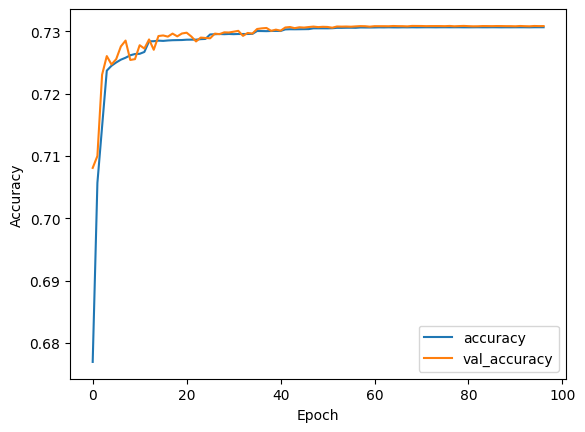

In [19]:
#plotting the accuracy of the first model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

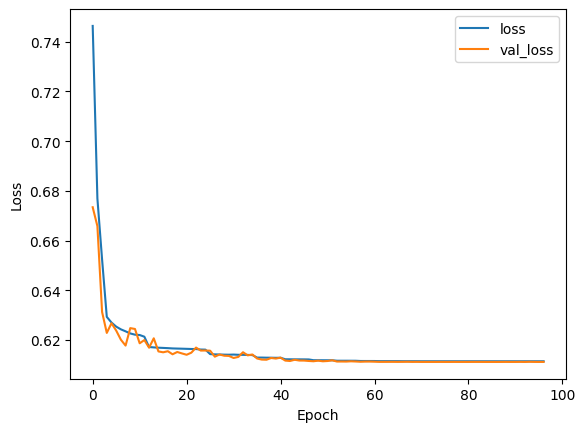

In [20]:
#plotting the loss over epoch for the first model
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [18]:
#save the first trained model
model.save('../models/model_SimpleRNN_whole.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
